In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import model_selection
from sklearn import metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
p_df = pd.read_csv('parkinsons.data')

In [3]:
p_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

In [4]:
p_df.eq(0).any().any()

True

In [5]:
df=p_df.mask(p_df==0).fillna(p_df.mean())

In [6]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1.0,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1.0,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1.0,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1.0,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1.0,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [7]:
df.shape

(195, 24)

In [8]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


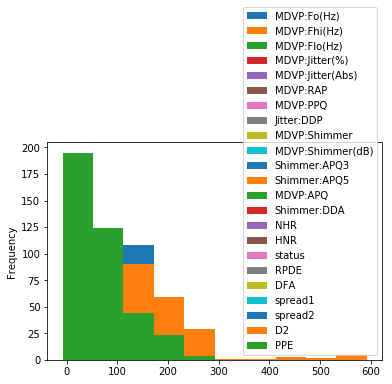

In [9]:
df.plot.hist()


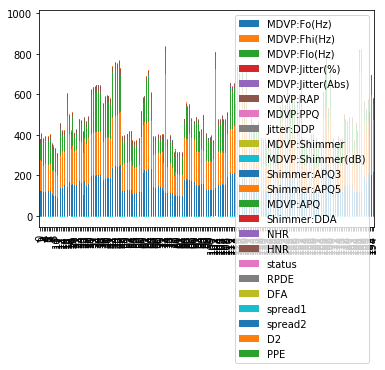

In [10]:
df.plot.bar(stacked=True)

C:\Users\MAYUR-PC\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


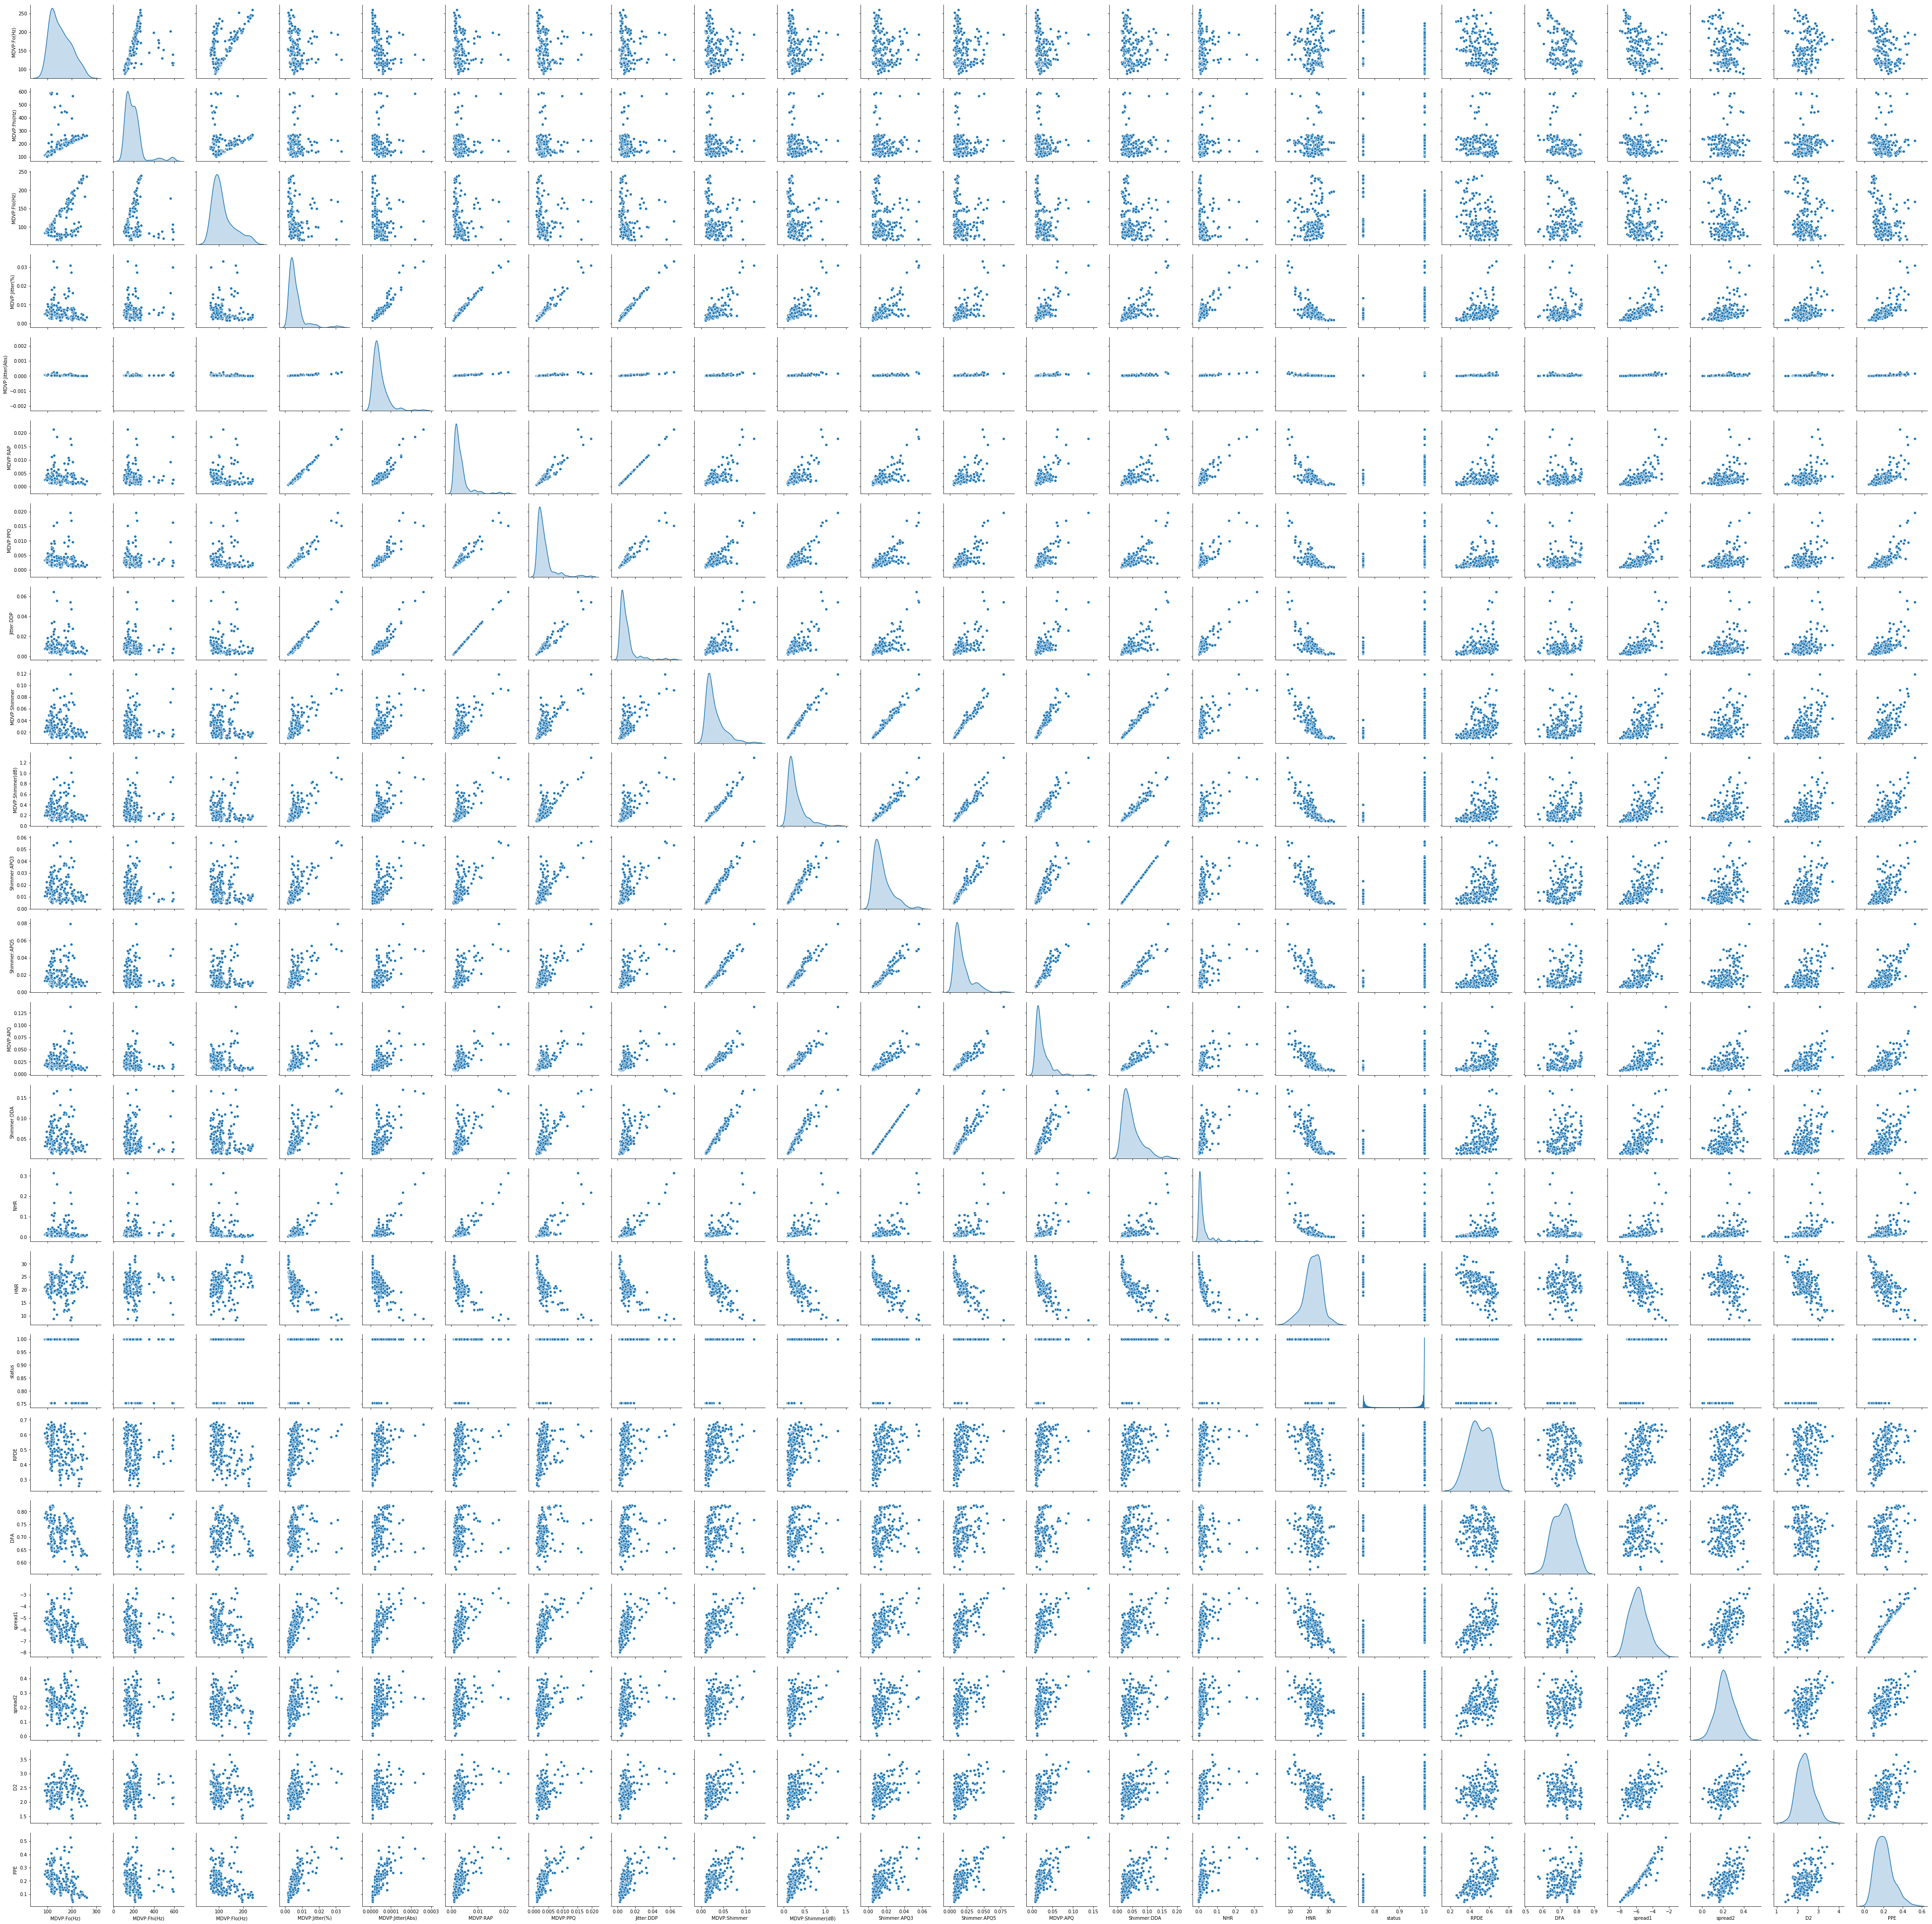

In [11]:
import seaborn as sns
sns.pairplot(df,diag_kind='kde')

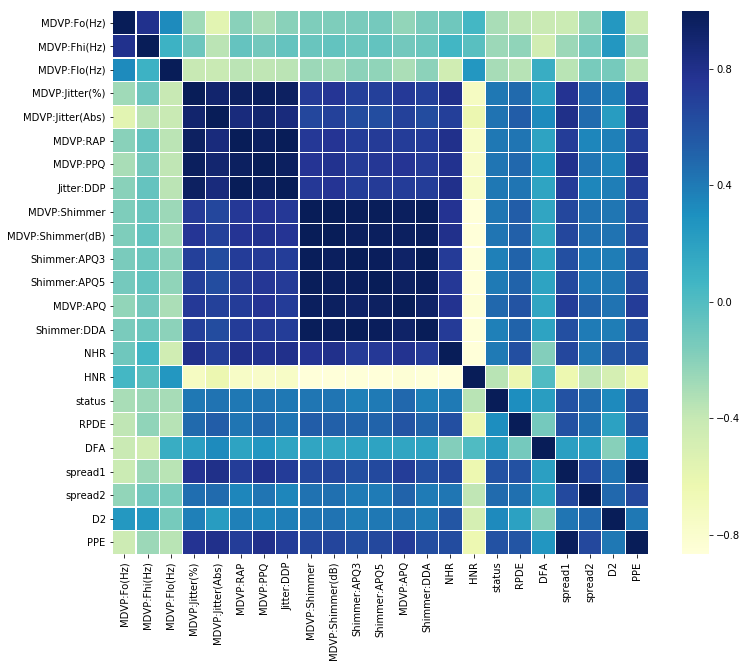

In [12]:
corrmat =df.corr(method='spearman')
f, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corrmat, ax=ax, cmap="YlGnBu", linewidths=0.1)

In [13]:
df=df.drop("name", axis=1)


In [14]:
X = df.drop("status", axis=1) #independent columns
y = df["status"]  #target column i.e price range



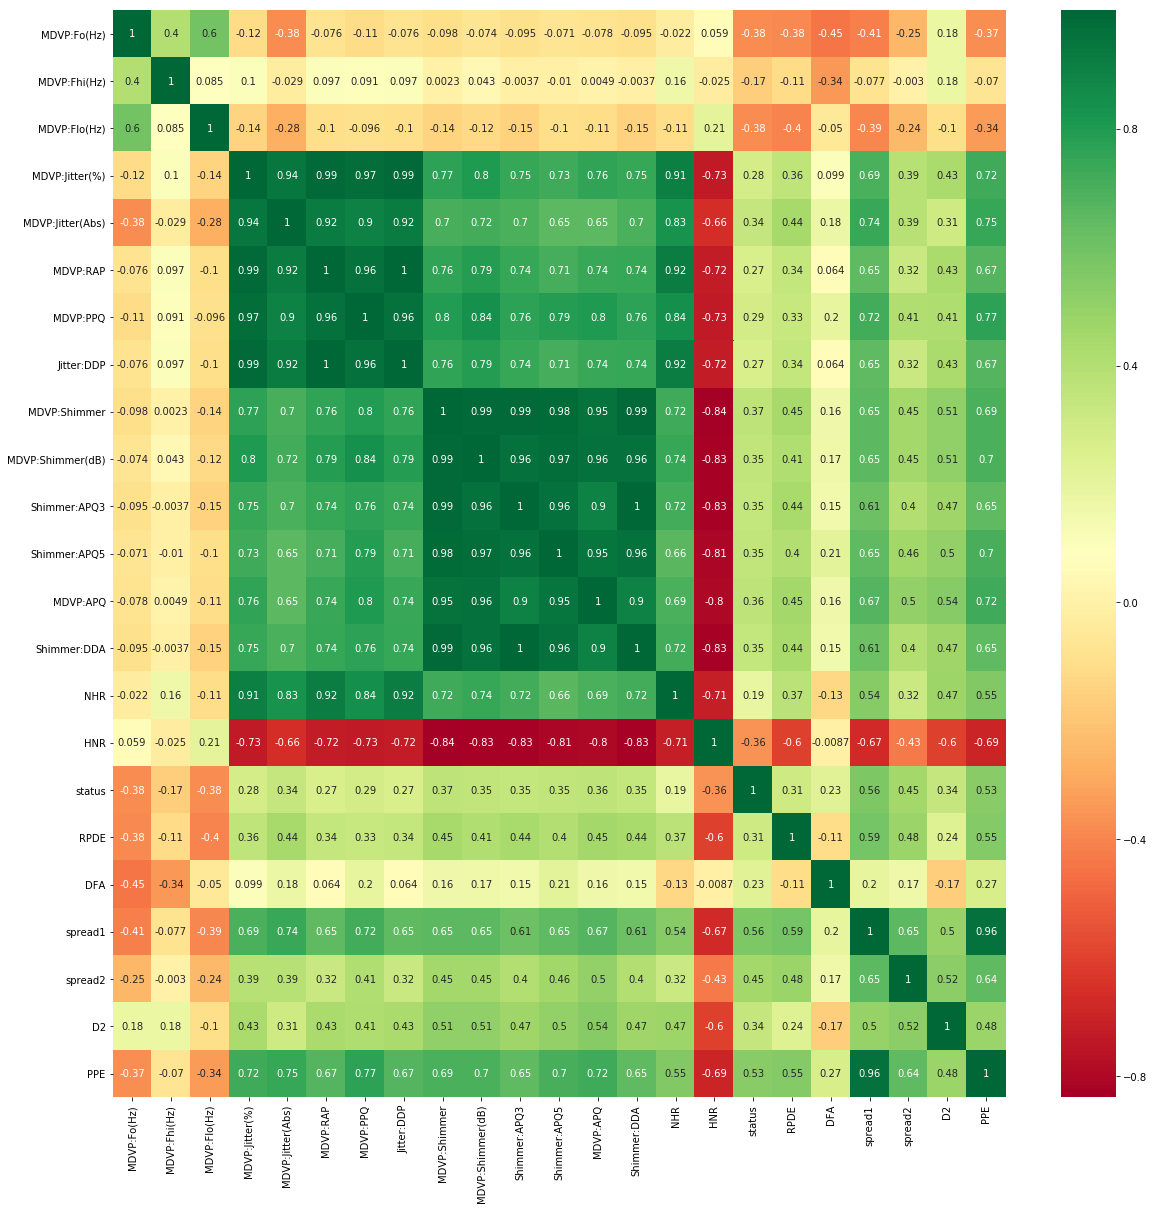

In [15]:
corrmat = df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot heat map
g=sns.heatmap(df[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [18]:
X = df.drop("MDVP:Fo(Hz)", axis=1)
X = X.drop("MDVP:Fhi(Hz)", axis=1)
X = X.drop("MDVP:Flo(Hz)", axis=1)
X = X.drop("HNR", axis=1)

In [19]:
X=X.astype(int)

In [20]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 19 columns):
MDVP:Jitter(%)      195 non-null int32
MDVP:Jitter(Abs)    195 non-null int32
MDVP:RAP            195 non-null int32
MDVP:PPQ            195 non-null int32
Jitter:DDP          195 non-null int32
MDVP:Shimmer        195 non-null int32
MDVP:Shimmer(dB)    195 non-null int32
Shimmer:APQ3        195 non-null int32
Shimmer:APQ5        195 non-null int32
MDVP:APQ            195 non-null int32
Shimmer:DDA         195 non-null int32
NHR                 195 non-null int32
status              195 non-null int32
RPDE                195 non-null int32
DFA                 195 non-null int32
spread1             195 non-null int32
spread2             195 non-null int32
D2                  195 non-null int32
PPE                 195 non-null int32
dtypes: int32(19)
memory usage: 14.6 KB


In [21]:
y = y.astype(int)

In [22]:
train_set, test_set, train_labels, test_labels = train_test_split(X, y, test_size=0.30, random_state=2)

In [23]:
df_model = DecisionTreeClassifier(criterion = 'entropy' ,random_state=0)

In [24]:
df_model.fit(train_set, train_labels)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

In [33]:
y_pred=df_model.predict(test_set)   # performance on test data
acc=metrics.accuracy_score(test_labels,y_pred)
print(acc)

1.0


In [34]:
cm=metrics.confusion_matrix(test_labels,y_pred)
print(cm)

[[12  0]
 [ 0 47]]


In [35]:
cr=metrics.classification_report(test_labels,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        47

   micro avg       1.00      1.00      1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59



In [36]:
#Perform Grid Search Method to find the optimal max_depth size
from sklearn.model_selection import GridSearchCV
parameter={'max_depth':np.arange(1,10)}
GS=GridSearchCV(df_model,parameter,cv=3)
GS.fit(X,y)


GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9])},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [37]:
GS.best_params_

{'max_depth': 1}

In [40]:
from IPython.display import Image  
#import pydotplus as pydot
from sklearn import tree
from os import system

train_char_label = ['1', '2', '3']
wine_Tree_File = open('wine_tree.dot','w')
dot_data = tree.export_graphviz(df_model, out_file=wine_Tree_File, feature_names = list(train_set), class_names = list(train_char_label))

wine_Tree_File.close()


# importance of features in the tree building ( The importance of a feature is computed as the 
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(df_model.feature_importances_, columns = ["Imp"], index = train_set.columns))


                  Imp
MDVP:Jitter(%)    0.0
MDVP:Jitter(Abs)  0.0
MDVP:RAP          0.0
MDVP:PPQ          0.0
Jitter:DDP        0.0
MDVP:Shimmer      0.0
MDVP:Shimmer(dB)  0.0
Shimmer:APQ3      0.0
Shimmer:APQ5      0.0
MDVP:APQ          0.0
Shimmer:DDA       0.0
NHR               0.0
status            1.0
RPDE              0.0
DFA               0.0
spread1           0.0
spread2           0.0
D2                0.0
PPE               0.0


In [ ]:
# You can also copy the script in the .dot file and paste it at http://webgraphviz.com/ to get tree view 
#or create a .png as below

system("dot -Tpng wine_tree.dot -o wine_tree.png")   # This command is to the OS
Image("wine_tree.png")        # use the image command to read the .png file and print on screen

In [42]:
dt_model2 = DecisionTreeClassifier(criterion = 'entropy', max_depth = 2)


In [43]:
dt_model2.fit(train_set, train_labels)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=2,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [49]:
wine_tree_regularized = open('wine_tree_regularized.dot','w')
dot_data = tree.export_graphviz(dt_model2, out_file= wine_tree_regularized , feature_names = list(train_set), class_names = list(train_char_label))

wine_tree_regularized.close()

print (pd.DataFrame(dt_model2.feature_importances_, columns = ["Imp"], index = train_set.columns))


                  Imp
MDVP:Jitter(%)    0.0
MDVP:Jitter(Abs)  0.0
MDVP:RAP          0.0
MDVP:PPQ          0.0
Jitter:DDP        0.0
MDVP:Shimmer      0.0
MDVP:Shimmer(dB)  0.0
Shimmer:APQ3      0.0
Shimmer:APQ5      0.0
MDVP:APQ          0.0
Shimmer:DDA       0.0
NHR               0.0
status            1.0
RPDE              0.0
DFA               0.0
spread1           0.0
spread2           0.0
D2                0.0
PPE               0.0
